<a href="https://colab.research.google.com/github/srishtiiwalia/Python_WebScraping/blob/main/1_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Stock Prediction

1. Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. Reading Data

In [ ]:
print("Downloading Dataset from Kaggle")
path = kagglehub.dataset_download("asadullahcreative/us-stock-market-historical-ohlcv-dataset")
print("Dataset downloaded")

csv_filename = "stock_prices_daily.csv"
full_path = os.path.join(path, csv_filename)

df = pd.read_csv(full_path)
print("\n\033[1;4m" + "Shape:" + "\033[0m" + f" {df.shape[0]:,} rows × {df.shape[1]} columns")

print("\n\033[1;4m" + "Dataset Basic Information" + "\033[0m")
print(df.info())

Using Colab cache for faster access to the 'us-stock-market-historical-ohlcv-dataset' dataset.
Dataset downloaded

Shape: 184,138 rows × 11 columns

Dataset Basic Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184138 entries, 0 to 184137
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Date          184138 non-null  object 
 1   Ticker        184138 non-null  object 
 2   Company_Name  184138 non-null  object 
 3   Sector        184138 non-null  object 
 4   Industry      184138 non-null  object 
 5   Open          184138 non-null  float64
 6   High          184138 non-null  float64
 7   Low           184138 non-null  float64
 8   Close         184138 non-null  float64
 9   Adj_Close     184138 non-null  float64
 10  Volume        184138 non-null  int64  
dtypes: float64(5), int64(1), object(5)
memory usage: 15.5+ MB
None


3. Sector Distribution

/tmp/ipykernel_35643/2659330010.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Sector', order=df['Sector'].value_counts().index, palette='viridis')


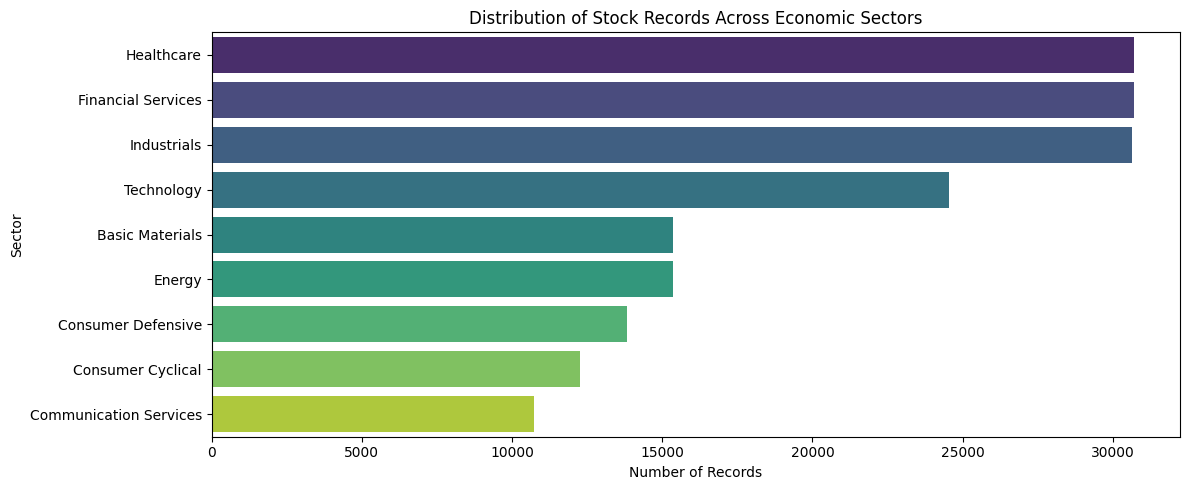

In [ ]:
if 'Sector' in df.columns:
    plt.figure(figsize=(12, 5))
    sns.countplot(data=df, y='Sector', order=df['Sector'].value_counts().index, palette='viridis')
    plt.title('Distribution of Stock Records Across Economic Sectors')
    plt.xlabel('Number of Records')
    plt.ylabel('Sector')
    plt.tight_layout()
    plt.savefig('sector_distribution.png')
    plt.show()

4. Target Correlation Matrix

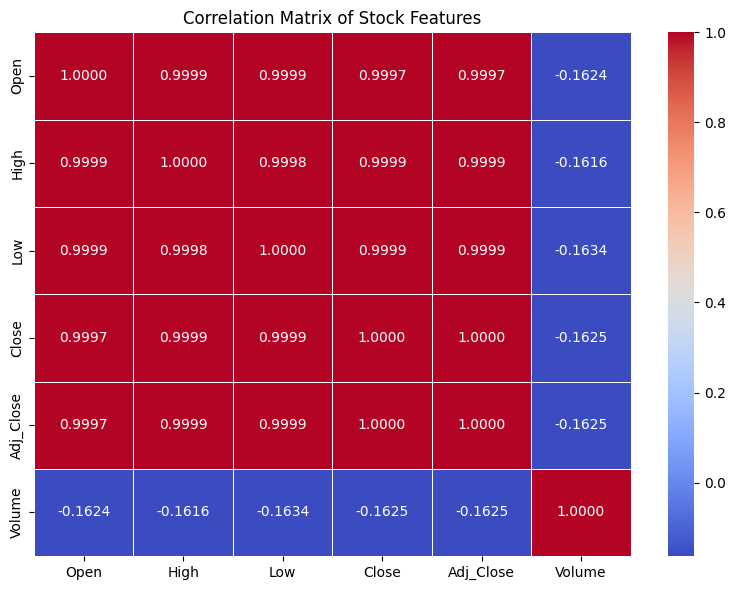

In [ ]:
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", linewidths=0.5)
plt.title('Correlation Matrix of Stock Features')
plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.show()

We see that the price features (Open, High, Low, and Close) are almost perfectly correlated, meaning they contain highly redundant information. Feeding all of them into our LSTM would introduce unnecessary noise and cause the model to overfit, using just the Close price would be better design choice, whereas Volume shows a very low correlation, thus being non-redundant.

5. Filter for a specific liquid stock to use for LSTM training

In [ ]:
ticker_column = 'Ticker' if 'Ticker' in df.columns else (df.columns[0] if 'Symbol' not in df.columns else 'Symbol')
target_ticker = 'AAPL' if 'AAPL' in df[ticker_column].values else df[ticker_column].iloc[0]

stock_df = df[df[ticker_column] == target_ticker].copy()
stock_df['Date'] = pd.to_datetime(stock_df['Date'])
stock_df = stock_df.sort_values('Date').reset_index(drop=True)

stock_df.to_csv('/content/drive/MyDrive/target_stock_raw.csv', index=False)
print(f"Saved isolated processed raw data for '{target_ticker}' to 'target_stock_raw.csv'")

/tmp/ipykernel_35643/3243978124.py:5: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  stock_df['Date'] = pd.to_datetime(stock_df['Date'])


Saved isolated processed raw data for 'AAPL' to 'target_stock_raw.csv'
